<a href="https://colab.research.google.com/github/karanbhatt1/MachineLearning/blob/main/TimeSeriesForecastingModel30_may.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🕗 Test Start Time: 9:00 PM to 10:30 PM

🧪 Test Type: Practice Test (No marks will be updated on your LMS account)

📤 Submission: Submit your completed Colab notebook using the Google Form link provided below -

https://forms.gle/CuB5WZSui3bCMW9n7


❌ No use of AI assistance (e.g., ChatGPT, Copilot, etc.) is allowed.

🔍 AI Plagiarism detection tools will be used to verify the authenticity of your work.

**After submitting you can leave**

# **Time Series Test Questions**

Dataset link : https://drive.google.com/file/d/13YPDaBOq0cvYz2GxUx2wVpwEEEAO1QS2/view?usp=sharing

**Q1. Check if the time series is stationary using the Augmented Dickey-Fuller (ADF) test. Print the p-value and interpret the result.**

**Q2. If the series is not stationary, apply appropriate transformation(s) (e.g., differencing or log transformation) to make it stationary. Confirm by re-running the ADF test.**

**Q3. Build atleast 3-4 Time series models (ARIMA , SARIMA , SARIMAX , FbPropher etc) , Forecast the next 1 month values using models and compare their predictions using MAE or RMSE.**


In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
dataset = pd.read_csv("Electric_Production.csv")

In [66]:
dataset.shape

(397, 2)

In [67]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        397 non-null    object 
 1   IPG2211A2N  397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [68]:
dataset['DATE'] = pd.to_datetime(dataset['DATE'])

In [69]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DATE        397 non-null    datetime64[ns]
 1   IPG2211A2N  397 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 6.3 KB


In [114]:
dataset.head(10)

,DATE,IPG2211A2N
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151
5,1985-06-01,58.0904
6,1985-07-01,62.6202
7,1985-08-01,63.2485
8,1985-09-01,60.5846
9,1985-10-01,56.3154


In [71]:
roll_mean = dataset['IPG2211A2N'].rolling(window=12).mean()
roll_std = dataset['IPG2211A2N'].rolling(window=12).std()

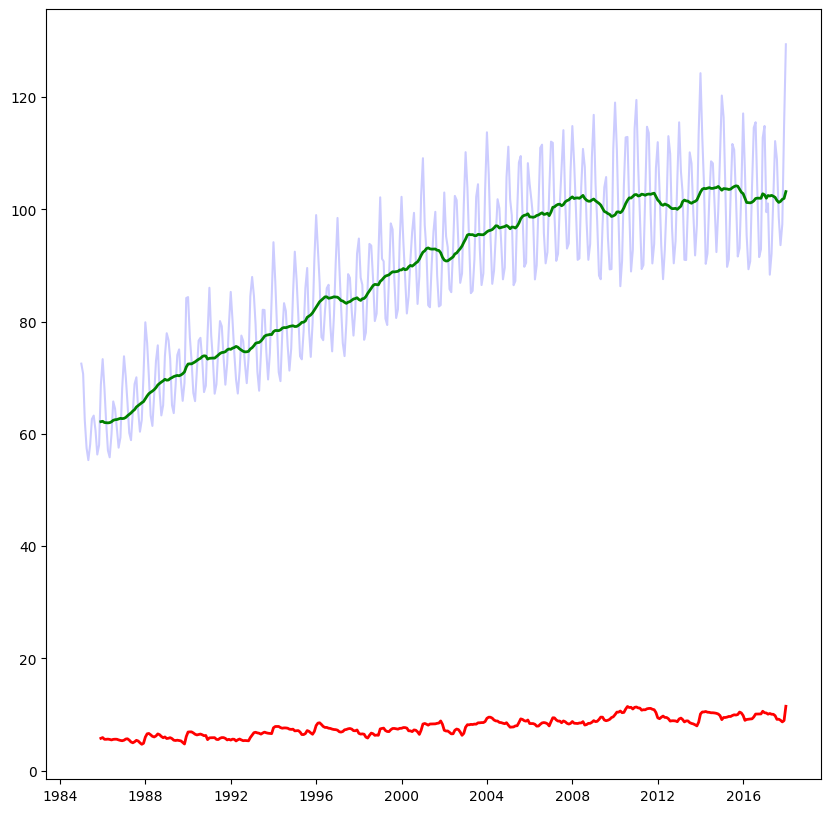

In [72]:
from matplotlib.lines import lineMarkers
from scipy.stats import alpha
plt.figure(figsize=(10,10))
plt.plot(dataset['DATE'], dataset['IPG2211A2N'],color='blue',alpha=0.2)
plt.plot(dataset['DATE'],roll_mean,label="rolling_mean",color="green", linewidth=2)
plt.plot(dataset['DATE'],roll_std,label="rolling_std", color="red",linewidth=2)
plt.show()

In [73]:
from statsmodels.tsa.stattools import adfuller

In [74]:
p_test = adfuller(dataset['IPG2211A2N'])

In [75]:
p_test

(np.float64(-2.256990350047235),
 np.float64(0.1862146911658712),
 15,
 381,
 {'1%': np.float64(-3.4476305904172904),
  '5%': np.float64(-2.869155980820355),
  '10%': np.float64(-2.570827146203181)},
 np.float64(1840.8474501627156))

In [76]:
dataset_cpy = dataset.copy()

In [79]:
dataset_cpy['IPG2211A2N'] = dataset_cpy['IPG2211A2N'].diff(12).diff(12)

In [83]:
roll_mean_1 = dataset_cpy['IPG2211A2N'].rolling(window=12).mean()
roll_std_1 = dataset_cpy['IPG2211A2N'].rolling(window=12).std()

In [84]:
dataset_cpy.dropna(inplace=True)

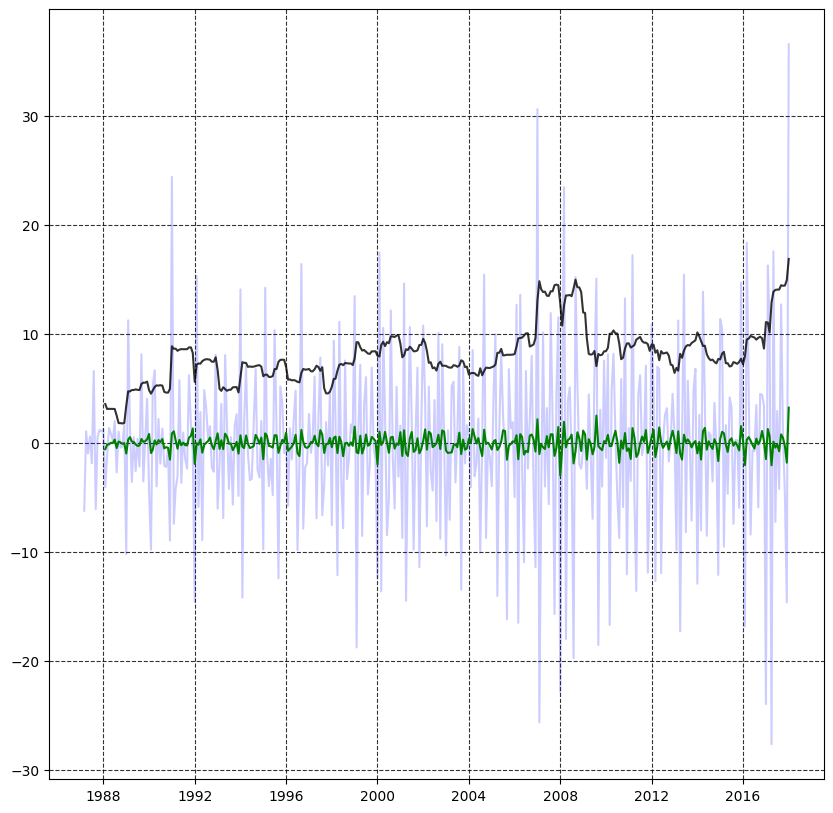

In [103]:
plt.figure(figsize=(10,10))
plt.plot(dataset_cpy['DATE'],dataset_cpy['IPG2211A2N'],label="Date && Time",color="blue",alpha=0.2)
plt.plot(dataset_cpy['DATE'],roll_mean_1,label="rolling_mean",color="green",alpha=1)
plt.plot(dataset_cpy['DATE'],roll_std_1,label = "rolling standard deviation", color="black",alpha=0.8)
plt.grid(True,alpha=0.8,linestyle = '--', color='black')


In [104]:
# Time Series Decomposition:

In [105]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [110]:
indexed_series = dataset_cpy.set_index('DATE')['IPG2211A2N'].dropna()
decompose_res = seasonal_decompose(indexed_series, model='additive', period=12)

In [118]:
seasonalty = decompose_res.seasonal

In [126]:
seasonalty['s']

,DATE,seasonal
0,1987-03-01,0.622027
1,1987-04-01,-0.604484
2,1987-05-01,0.294521
3,1987-06-01,-0.185883
4,1987-07-01,0.156413
...,...,...
366,2017-09-01,-0.237037
367,2017-10-01,0.069514
368,2017-11-01,0.085487
369,2017-12-01,0.412774


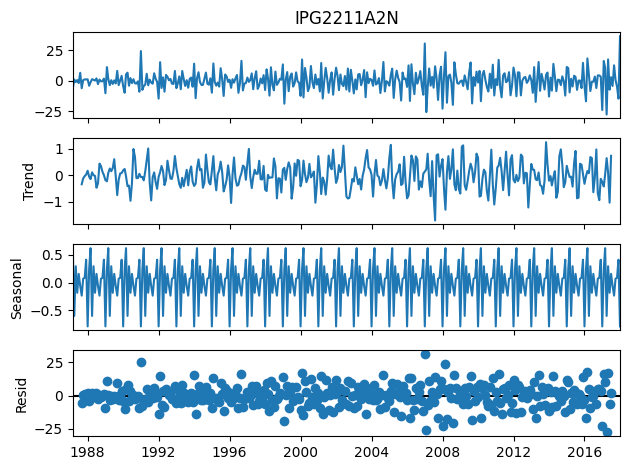

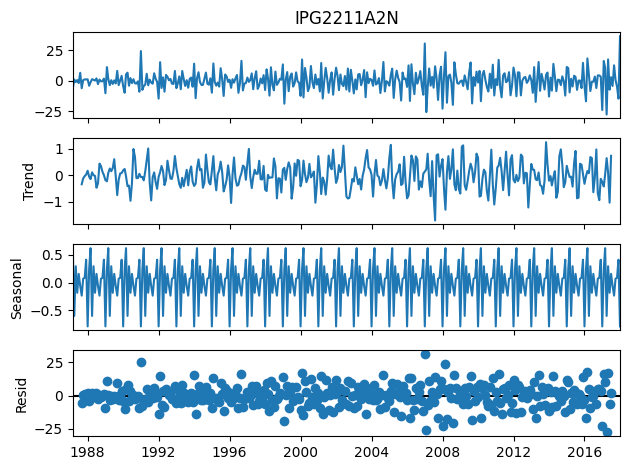

In [111]:
decompose_res.plot()

In [112]:
plt.show()

In [86]:
# Performing ADF test

In [87]:
from statsmodels.tsa.stattools import adfuller

In [88]:
p_test = adfuller(dataset_cpy['IPG2211A2N'])

In [89]:
print(f'The p value of the data is {p_test[1]}')
print("We can reject the null hyptothesis")

The p value of the data is 5.793760230550975e-14
We can reject the null hyptothesis


In [90]:
# ploting ACF and PACF

In [91]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf

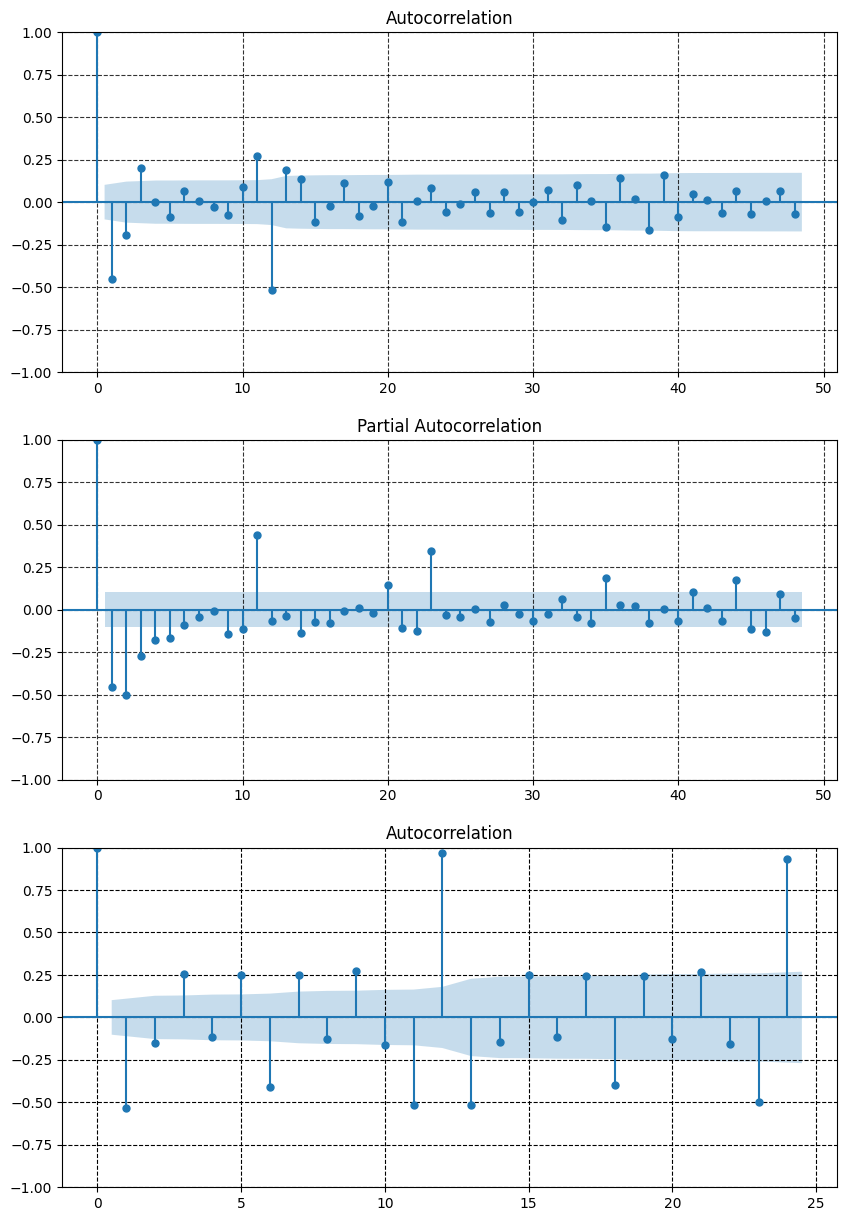

In [133]:
fig,axs = plt.subplots(3,1,figsize=(10,15))
plot_acf(dataset_cpy['IPG2211A2N'],ax=axs[0],lags = 48)
axs[0].grid(True, linestyle='--', alpha=0.8,color='black')
plot_acf(seasonalty,ax=axs[2],lags=24)
axs[2].grid(True,linestyle='--',color='black')
plot_pacf(dataset_cpy['IPG2211A2N'], ax=axs[1],lags = 48)
axs[1].grid(True, linestyle='--', alpha=0.8,color='black')
plt.show()

In [134]:
# Finaly Modelling Using SARIMA Having seasonality of 12 months, AR(P) where p = 2 and MA(q) => 1;

In [135]:
from statsmodels.tsa.statespace.sarimax import SARIMAX,SARIMAXResults

In [137]:
model_1 = SARIMAX(dataset_cpy['IPG2211A2N'], order=(2,0,1),seasonal_order=(2,0,1,12))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [138]:
model_1 = model_1.fit()

In [139]:
dataset_cpy['Prediction'] = model_1.predict(start=0,end=len(dataset_cpy)-1)

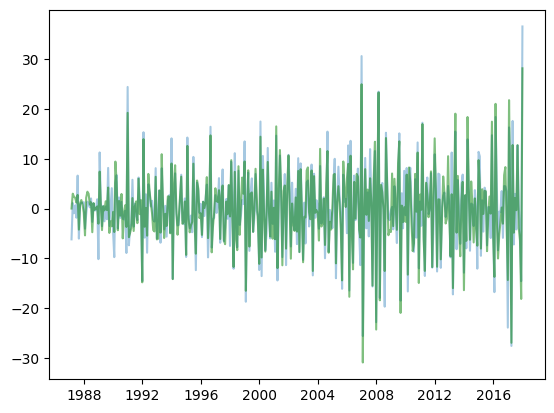

In [142]:
plt.plot(dataset_cpy['DATE'],dataset_cpy['IPG2211A2N'],alpha=0.4)
plt.plot(dataset_cpy['DATE'],dataset_cpy['Prediction'],alpha=0.5,color='green')

# Using Dynamic = True

In [143]:
model_2 = SARIMAX(dataset_cpy['IPG2211A2N'],order=(2,0,1),seasonal_order=(2,0,1,12),dynamic = True)
model_2 = model_2.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['dynamic']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [144]:
predictions = model_2.predict(start=0,end=len(dataset_cpy)-1)

Text(0, 0.5, 'Predictions')

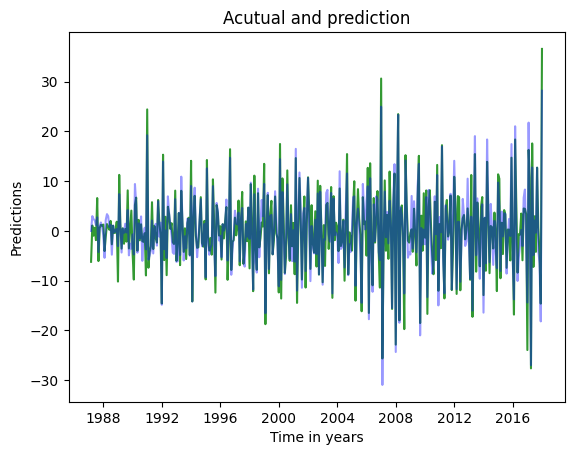

In [147]:
plt.plot(dataset_cpy['DATE'],dataset_cpy['IPG2211A2N'],color="green",alpha=0.8)
plt.plot(dataset_cpy['DATE'],predictions,color = 'blue',alpha=0.4)
plt.title("Acutual and prediction")
plt.xlabel("Time in years")
plt.ylabel("Predictions")

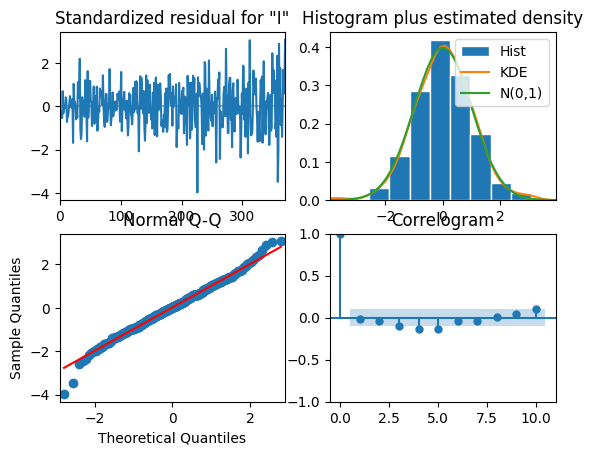

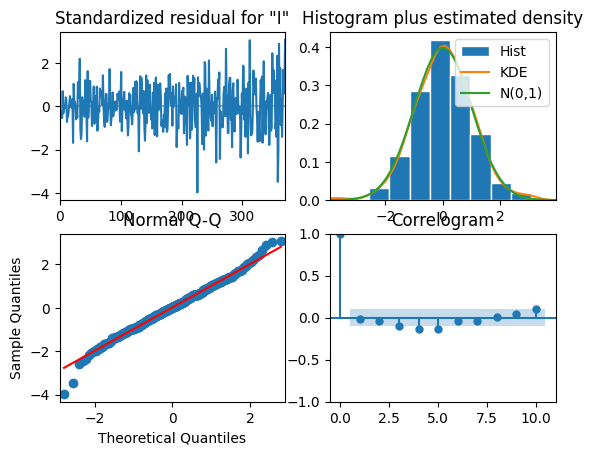

In [148]:
model_2.plot_diagnostics()

#Evaluation OF MODEL
**Model SARIMAX with oreders**
- p 2
- d 0
- q 1
- s 12

model_2 with dyanmic = True is used to forecast the next 2 years values

In [159]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

In [160]:
dataset_cpy.columns

Index(['DATE', 'IPG2211A2N', 'Prediction'], dtype='object')

In [161]:
mae = mean_absolute_error(dataset_cpy['IPG2211A2N'],dataset_cpy['Prediction'])

In [162]:
print(f"MAE:{mae}")

MAE:2.2719341348313535


In [163]:
rmse = np.sqrt(mean_squared_error(dataset_cpy['IPG2211A2N'],dataset_cpy['Prediction']))
print(f"RMSE: {rmse}")

RMSE: 2.890203489125195


In [164]:
r2 = r2_score(dataset_cpy['IPG2211A2N'],dataset_cpy['Prediction'])
print(f"R2 Score: {r2}")

R2 Score: 0.879706263919166


# Forecasting next 2 years values

In [170]:
dataset_cpy.drop(['Prediction'],axis=1,inplace=True)

In [171]:
dataset_cpy

,DATE,IPG2211A2N
26,1987-03-01,-6.1954
27,1987-04-01,1.0924
28,1987-05-01,-0.9513
29,1987-06-01,0.6232
30,1987-07-01,-1.8427
...,...,...
392,2017-09-01,12.7344
393,2017-10-01,0.7113
394,2017-11-01,-4.8453
395,2017-12-01,-14.5985


TypeError: statsmodels.tsa.statespace.mlemodel.MLEResults.predict() got multiple values for keyword argument 'start'

<Axes: >

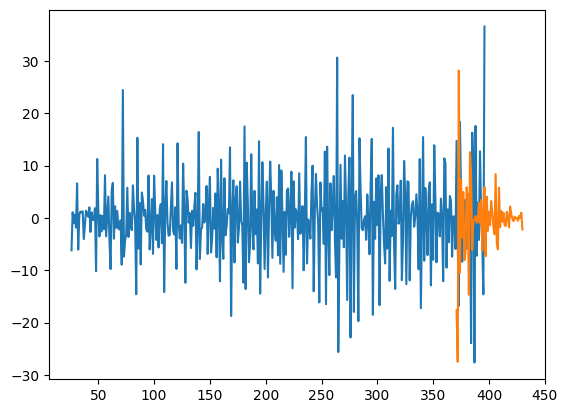

In [175]:
dataset_cpy['IPG2211A2N'].plot()
pred.plot()